# Original TeleSABRE vs BLaRTSABRE

In [63]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

plt.rcParams.update({
    "figure.dpi": 150,
    "figure.figsize": (12, 6),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 10,
})

C_BLaRT = "#2563eb"
C_TELE  = "#e11d48"

In [64]:
BLaRT_PATH = "BLaRTSABRE_improved.json"
TELE_PATH  = "og_telesabre_opt_true.json"

with open(BLaRT_PATH) as f:
    BLaRT_raw = json.load(f)
with open(TELE_PATH) as f:
    tele_raw = json.load(f)

# Handle both list-of-dicts and dict-of-dicts
if isinstance(BLaRT_raw, dict):
    BLaRT_raw = list(BLaRT_raw.values())
if isinstance(tele_raw, dict):
    tele_raw = list(tele_raw.values())

# Match circuits by name
BLaRT_by_name = {r["name"]: r for r in BLaRT_raw}
tele_by_name  = {r["name"]: r for r in tele_raw}
names = sorted(set(BLaRT_by_name) & set(tele_by_name))

BLaRT = [BLaRT_by_name[n] for n in names]
tele  = [tele_by_name[n] for n in names]

print(f"{len(names)} circuits")
for n in names:
    print(f"  {n}")

10 circuits
  ae_nativegates_ibm_qiskit_opt3_25
  ae_nativegates_ibm_qiskit_opt3_64
  ghz_nativegates_ibm_qiskit_opt3_25
  ghz_nativegates_ibm_qiskit_opt3_64
  graphstate_nativegates_ibm_qiskit_opt3_25
  graphstate_nativegates_ibm_qiskit_opt3_64
  qft_nativegates_ibm_qiskit_opt3_25
  qft_nativegates_ibm_qiskit_opt3_64
  random_nativegates_ibm_qiskit_opt3_25
  random_nativegates_ibm_qiskit_opt3_64


In [65]:
# Original circuit properties
og_cx = np.array([b["og_cx"] for b in BLaRT])
og_depth = np.array([b["og_depth"] for b in BLaRT])
og_size = np.array([b["og_size"] for b in BLaRT])
num_qubits = np.array([b["num_qubits"] for b in BLaRT])

# BLaRT SABRE
b_local_swaps = np.array([b["local_swaps"] for b in BLaRT])
b_remote_swaps = np.array([b["remote_swaps"] for b in BLaRT])
b_telegates = np.array([b["telegates"] for b in BLaRT])
b_time = np.array([b["mapping_time"] / b["iterations"] for b in BLaRT])

# TeleSABRE
t_swaps     = np.array([t["swaps"] for t in tele])
t_teleports = np.array([t["teleports"] for t in tele])
t_telegates = np.array([t["telegates"] for t in tele])
t_time      = np.array([t["mapping_time"] / t["iterations"] for t in tele])
t_fail   = np.array([t["solving_deadlock"] for t in tele])

# Derived: inter-core ops
b_remote_ops = b_remote_swaps + b_telegates
t_remote_ops = t_teleports + t_telegates

In [66]:
def short_name(name, max_len=20):
    name = name.replace("_nativegates_ibm_qiskit_opt3", "")
    name = name.replace("_nativegates_ibm_qiskit", "")
    return name[:max_len]

def yn(x):
    return "Y" if x else "N"

# Derived metrics
b_total_swaps = b_local_swaps + b_remote_swaps
t_total_moves = t_swaps + t_teleports

# Column widths
W_NAME = 20
W_FAIL = 6
W_QB   = 3
W_B1   = 7
W_T1   = 7
W_D1   = 7
W_CMP  = 3
W_BTG  = 6
W_TTG  = 6
W_DTG  = 7
W_BREM = 8
W_TREM = 8
W_DREM = 7
W_BT   = 7
W_TT   = 7
W_DT   = 8

header = (
    f"{'Circuit':<{W_NAME}} {'T_fail':>{W_FAIL}} {'Qb':>{W_QB}} | "
    f"{'B_L+R':>{W_B1}} {'T_S+T':>{W_T1}} {'Δ':>{W_D1}} {'B<T':>{W_CMP}} | "
    f"{'B_TG':>{W_BTG}} {'T_TG':>{W_TTG}} {'Δ':>{W_DTG}} {'B<T':>{W_CMP}} | "
    f"{'B_RemOp':>{W_BREM}} {'T_RemOp':>{W_TREM}} {'Δ':>{W_DREM}} {'B<T':>{W_CMP}} | "
    f"{'B_t(s)':>{W_BT}} {'T_t(s)':>{W_TT}} {'Δ':>{W_DT}} {'B<T':>{W_CMP}}"
)

print(header)
print("=" * len(header))

# summary counters
moves_better = 0
tg_better = 0
rem_better = 0
time_better = 0

d_moves_list = []
d_tg_list = []
d_rem_list = []
d_time_list = []

for i, name in enumerate(names):
    failed = bool(t_fail[i])

    if failed:
        t_moves_disp = "FAIL"
        t_tg_disp    = "FAIL"
        t_rem_disp   = "FAIL"
        t_time_disp  = "FAIL"

        d_moves_disp = "FAIL"
        d_tg_disp    = "FAIL"
        d_rem_disp   = "FAIL"
        d_time_disp  = "FAIL"

        moves_win = True
        tg_win    = True
        rem_win   = True
        time_win  = True
    else:
        d_moves = b_total_swaps[i] - t_total_moves[i]
        d_tg    = b_telegates[i] - t_telegates[i]
        d_rem   = b_remote_ops[i] - t_remote_ops[i]
        d_time  = b_time[i] - t_time[i]

        t_moves_disp = f"{t_total_moves[i]:>{W_T1}.0f}"
        t_tg_disp    = f"{t_telegates[i]:>{W_TTG}.0f}"
        t_rem_disp   = f"{t_remote_ops[i]:>{W_TREM}.0f}"
        t_time_disp  = f"{t_time[i]:>{W_TT}.1f}"

        d_moves_disp = f"{d_moves:+{W_D1}.0f}"
        d_tg_disp    = f"{d_tg:+{W_DTG}.0f}"
        d_rem_disp   = f"{d_rem:+{W_DREM}.0f}"
        d_time_disp  = f"{d_time:+{W_DT}.1f}"

        d_moves_list.append(d_moves)
        d_tg_list.append(d_tg)
        d_rem_list.append(d_rem)
        d_time_list.append(d_time)

        moves_win = d_moves < 0
        tg_win    = d_tg < 0
        rem_win   = d_rem < 0
        time_win  = d_time < 0

    moves_better += int(moves_win)
    tg_better    += int(tg_win)
    rem_better   += int(rem_win)
    time_better  += int(time_win)

    print(
        f"{short_name(name):<{W_NAME}} {yn(failed):>{W_FAIL}} {num_qubits[i]:>{W_QB}} | "
        f"{b_total_swaps[i]:>{W_B1}.0f} {t_moves_disp:>{W_T1}} {d_moves_disp:>{W_D1}} {yn(moves_win):>{W_CMP}} | "
        f"{b_telegates[i]:>{W_BTG}.0f} {t_tg_disp:>{W_TTG}} {d_tg_disp:>{W_DTG}} {yn(tg_win):>{W_CMP}} | "
        f"{b_remote_ops[i]:>{W_BREM}.0f} {t_rem_disp:>{W_TREM}} {d_rem_disp:>{W_DREM}} {yn(rem_win):>{W_CMP}} | "
        f"{b_time[i]:>{W_BT}.1f} {t_time_disp:>{W_TT}} {d_time_disp:>{W_DT}} {yn(time_win):>{W_CMP}}"
    )

print("=" * len(header))

n = len(names)
tele_fail_count = int(np.sum(t_fail))

print(
    f"{'BETTER COUNT':<{W_NAME}} {'':>{W_FAIL}} {'':>{W_QB}} | "
    f"{'':>{W_B1}} {'':>{W_T1}} {f'{moves_better}/{n}':>{W_D1}} {'':>{W_CMP}} | "
    f"{'':>{W_BTG}} {'':>{W_TTG}} {f'{tg_better}/{n}':>{W_DTG}} {'':>{W_CMP}} | "
    f"{'':>{W_BREM}} {'':>{W_TREM}} {f'{rem_better}/{n}':>{W_DREM}} {'':>{W_CMP}} | "
    f"{'':>{W_BT}} {'':>{W_TT}} {f'{time_better}/{n}':>{W_DT}} {'':>{W_CMP}}"
)

print(
    f"{'T_FAIL COUNT':<{W_NAME}} {'':>{W_FAIL}} {'':>{W_QB}} | "
    f"{'':>{W_B1}} {'':>{W_T1}} {f'{tele_fail_count}/{n}':>{W_D1}} {'':>{W_CMP}} | "
    f"{'':>{W_BTG}} {'':>{W_TTG}} {'':>{W_DTG}} {'':>{W_CMP}} | "
    f"{'':>{W_BREM}} {'':>{W_TREM}} {'':>{W_DREM}} {'':>{W_CMP}} | "
    f"{'':>{W_BT}} {'':>{W_TT}} {'':>{W_DT}} {'':>{W_CMP}}"
)

if d_moves_list:
    d_moves_arr = np.array(d_moves_list, dtype=float)
    d_tg_arr    = np.array(d_tg_list, dtype=float)
    d_rem_arr   = np.array(d_rem_list, dtype=float)
    d_time_arr  = np.array(d_time_list, dtype=float)

    print(
        f"{'MEAN Δ (B-T)':<{W_NAME}} {'':>{W_FAIL}} {'':>{W_QB}} | "
        f"{'':>{W_B1}} {'':>{W_T1}} {np.mean(d_moves_arr):>{W_D1}.1f} {'':>{W_CMP}} | "
        f"{'':>{W_BTG}} {'':>{W_TTG}} {np.mean(d_tg_arr):>{W_DTG}.1f} {'':>{W_CMP}} | "
        f"{'':>{W_BREM}} {'':>{W_TREM}} {np.mean(d_rem_arr):>{W_DREM}.1f} {'':>{W_CMP}} | "
        f"{'':>{W_BT}} {'':>{W_TT}} {np.mean(d_time_arr):>{W_DT}.1f} {'':>{W_CMP}}"
    )

    print(
        f"{'MEDIAN Δ (B-T)':<{W_NAME}} {'':>{W_FAIL}} {'':>{W_QB}} | "
        f"{'':>{W_B1}} {'':>{W_T1}} {np.median(d_moves_arr):>{W_D1}.1f} {'':>{W_CMP}} | "
        f"{'':>{W_BTG}} {'':>{W_TTG}} {np.median(d_tg_arr):>{W_DTG}.1f} {'':>{W_CMP}} | "
        f"{'':>{W_BREM}} {'':>{W_TREM}} {np.median(d_rem_arr):>{W_DREM}.1f} {'':>{W_CMP}} | "
        f"{'':>{W_BT}} {'':>{W_TT}} {np.median(d_time_arr):>{W_DT}.1f} {'':>{W_CMP}}"
    )

Circuit              T_fail  Qb |   B_L+R   T_S+T       Δ B<T |   B_TG   T_TG       Δ B<T |  B_RemOp  T_RemOp       Δ B<T |  B_t(s)  T_t(s)        Δ B<T
ae_25                     N  25 |     236     414    -178   Y |     78     14     +64   N |      168       88     +80   N |    41.3    58.5    -17.3   Y
ae_64                     N  64 |    1058    2549   -1491   Y |    230     80    +150   N |      630      391    +239   N |   599.8   656.8    -57.0   Y
ghz_25                    N  25 |      22       9     +13   N |      0      0      +0   N |       11        2      +9   N |     0.1     1.0     -0.8   Y
ghz_64                    N  64 |     101      38     +63   N |      0      0      +0   N |       45        6     +39   N |     0.7     2.7     -2.0   Y
graphstate_25             N  25 |      11      18      -7   Y |      3      1      +2   N |        8        4      +4   N |     0.5     4.0     -3.6   Y
graphstate_64             N  64 |      84     147     -63   Y |      5      2     

> B_L+R = BLaRTSABRE local swaps + remote swaps

> T_S+T = TeleSABRE local swaps + teleports

> B_TG = BLaRTSABRE telegates

> T_TG = TeleSABRE telegates

> B_RemOp = BLaRTSABRE remote swaps + telegates

> B_RemOp = TeleSABRE teleports + telegates

> B_t(s) = BLaRTSABRE run time

> T_t(s) = TeleSABRE run time

---

In [67]:
# Original circuit properties
og_cx = np.array([b["og_cx"] for b in BLaRT])
og_depth = np.array([b["og_depth"] for b in BLaRT])
og_size = np.array([b["og_size"] for b in BLaRT])
num_qubits = np.array([b["num_qubits"] for b in BLaRT])

# BLaRT SABRE
b_local_swaps = np.array([b["local_swaps"] for b in BLaRT])
b_remote_swaps = np.array([b["remote_swaps"] for b in BLaRT])
b_telegates = np.array([b["telegates"] for b in BLaRT])
b_time = np.array([b["mapping_time"] / b["iterations"] for b in BLaRT])

# TeleSABRE, C implementation only
tc_swaps      = np.array([t["c"]["swaps"] for t in tele])
tc_teleports  = np.array([t["c"]["teleports"] for t in tele])
tc_telegates  = np.array([t["c"]["telegates"] for t in tele])
tc_success    = np.array([t["c"]["success"] for t in tele])
tc_fail       = ~tc_success

# Derived metrics
b_total_swaps = b_local_swaps + b_remote_swaps
b_remote_ops  = b_remote_swaps + b_telegates

tc_total_moves = tc_swaps + tc_teleports
tc_remote_ops  = tc_teleports + tc_telegates

def short_name(name, max_len=20):
    name = name.replace("_nativegates_ibm_qiskit_opt3", "")
    name = name.replace("_nativegates_ibm_qiskit", "")
    return name[:max_len]

def yn(x):
    return "Y" if x else "N"

# Column widths
W_NAME = 20
W_FAIL = 6
W_QB   = 3
W_B1   = 7
W_T1   = 7
W_D1   = 7
W_CMP  = 3
W_BTG  = 6
W_TTG  = 6
W_DTG  = 7
W_BREM = 8
W_TREM = 8
W_DREM = 7

header = (
    f"{'Circuit':<{W_NAME}} {'C_fail':>{W_FAIL}} {'Qb':>{W_QB}} | "
    f"{'B_L+R':>{W_B1}} {'C_S+T':>{W_T1}} {'Δ':>{W_D1}} {'B<C':>{W_CMP}} | "
    f"{'B_TG':>{W_BTG}} {'C_TG':>{W_TTG}} {'Δ':>{W_DTG}} {'B<C':>{W_CMP}} | "
    f"{'B_RemOp':>{W_BREM}} {'C_RemOp':>{W_TREM}} {'Δ':>{W_DREM}} {'B<C':>{W_CMP}}"
)

print(header)
print("=" * len(header))

moves_better = 0
tg_better = 0
rem_better = 0

d_moves_list = []
d_tg_list = []
d_rem_list = []

for i, name in enumerate(names):
    failed = bool(tc_fail[i])

    if failed:
        tc_moves_disp = "FAIL"
        tc_tg_disp    = "FAIL"
        tc_rem_disp   = "FAIL"

        d_moves_disp = "FAIL"
        d_tg_disp    = "FAIL"
        d_rem_disp   = "FAIL"

        moves_win = True
        tg_win    = True
        rem_win   = True
    else:
        d_moves = b_total_swaps[i] - tc_total_moves[i]
        d_tg    = b_telegates[i] - tc_telegates[i]
        d_rem   = b_remote_ops[i] - tc_remote_ops[i]

        tc_moves_disp = f"{tc_total_moves[i]:>{W_T1}.0f}"
        tc_tg_disp    = f"{tc_telegates[i]:>{W_TTG}.0f}"
        tc_rem_disp   = f"{tc_remote_ops[i]:>{W_TREM}.0f}"

        d_moves_disp = f"{d_moves:+{W_D1}.0f}"
        d_tg_disp    = f"{d_tg:+{W_DTG}.0f}"
        d_rem_disp   = f"{d_rem:+{W_DREM}.0f}"

        d_moves_list.append(d_moves)
        d_tg_list.append(d_tg)
        d_rem_list.append(d_rem)

        moves_win = d_moves < 0
        tg_win    = d_tg < 0
        rem_win   = d_rem < 0

    moves_better += int(moves_win)
    tg_better    += int(tg_win)
    rem_better   += int(rem_win)

    print(
        f"{short_name(name):<{W_NAME}} {yn(failed):>{W_FAIL}} {num_qubits[i]:>{W_QB}} | "
        f"{b_total_swaps[i]:>{W_B1}.0f} {tc_moves_disp:>{W_T1}} {d_moves_disp:>{W_D1}} {yn(moves_win):>{W_CMP}} | "
        f"{b_telegates[i]:>{W_BTG}.0f} {tc_tg_disp:>{W_TTG}} {d_tg_disp:>{W_DTG}} {yn(tg_win):>{W_CMP}} | "
        f"{b_remote_ops[i]:>{W_BREM}.0f} {tc_rem_disp:>{W_TREM}} {d_rem_disp:>{W_DREM}} {yn(rem_win):>{W_CMP}}"
    )

print("=" * len(header))

n = len(names)
c_fail_count = int(np.sum(tc_fail))

print(
    f"{'BETTER COUNT':<{W_NAME}} {'':>{W_FAIL}} {'':>{W_QB}} | "
    f"{'':>{W_B1}} {'':>{W_T1}} {f'{moves_better}/{n}':>{W_D1}} {'':>{W_CMP}} | "
    f"{'':>{W_BTG}} {'':>{W_TTG}} {f'{tg_better}/{n}':>{W_DTG}} {'':>{W_CMP}} | "
    f"{'':>{W_BREM}} {'':>{W_TREM}} {f'{rem_better}/{n}':>{W_DREM}} {'':>{W_CMP}}"
)

print(
    f"{'C_FAIL COUNT':<{W_NAME}} {'':>{W_FAIL}} {'':>{W_QB}} | "
    f"{'':>{W_B1}} {'':>{W_T1}} {f'{c_fail_count}/{n}':>{W_D1}} {'':>{W_CMP}} | "
    f"{'':>{W_BTG}} {'':>{W_TTG}} {'':>{W_DTG}} {'':>{W_CMP}} | "
    f"{'':>{W_BREM}} {'':>{W_TREM}} {'':>{W_DREM}} {'':>{W_CMP}}"
)

if d_moves_list:
    d_moves_arr = np.array(d_moves_list, dtype=float)
    d_tg_arr    = np.array(d_tg_list, dtype=float)
    d_rem_arr   = np.array(d_rem_list, dtype=float)

    print(
        f"{'MEAN Δ (B-C)':<{W_NAME}} {'':>{W_FAIL}} {'':>{W_QB}} | "
        f"{'':>{W_B1}} {'':>{W_T1}} {np.mean(d_moves_arr):>{W_D1}.1f} {'':>{W_CMP}} | "
        f"{'':>{W_BTG}} {'':>{W_TTG}} {np.mean(d_tg_arr):>{W_DTG}.1f} {'':>{W_CMP}} | "
        f"{'':>{W_BREM}} {'':>{W_TREM}} {np.mean(d_rem_arr):>{W_DREM}.1f} {'':>{W_CMP}}"
    )

    print(
        f"{'MEDIAN Δ (B-C)':<{W_NAME}} {'':>{W_FAIL}} {'':>{W_QB}} | "
        f"{'':>{W_B1}} {'':>{W_T1}} {np.median(d_moves_arr):>{W_D1}.1f} {'':>{W_CMP}} | "
        f"{'':>{W_BTG}} {'':>{W_TTG}} {np.median(d_tg_arr):>{W_DTG}.1f} {'':>{W_CMP}} | "
        f"{'':>{W_BREM}} {'':>{W_TREM}} {np.median(d_rem_arr):>{W_DREM}.1f} {'':>{W_CMP}}"
    )

Circuit              C_fail  Qb |   B_L+R   C_S+T       Δ B<C |   B_TG   C_TG       Δ B<C |  B_RemOp  C_RemOp       Δ B<C
ae_25                     N  25 |     236     440    -204   Y |     78      0     +78   N |      168       79     +89   N
ae_64                     N  64 |    1058    1753    -695   Y |    230     94    +136   N |      630      353    +277   N
ghz_25                    N  25 |      22      34     -12   Y |      0      0      +0   N |       11        7      +4   N
ghz_64                    N  64 |     101     148     -47   Y |      0      0      +0   N |       45       16     +29   N
graphstate_25             N  25 |      11      84     -73   Y |      3      1      +2   N |        8       23     -15   Y
graphstate_64             N  64 |      84     341    -257   Y |      5      2      +3   N |       36       62     -26   Y
qft_25                    N  25 |     238     533    -295   Y |     88      7     +81   N |      199      104     +95   N
qft_64                  

---

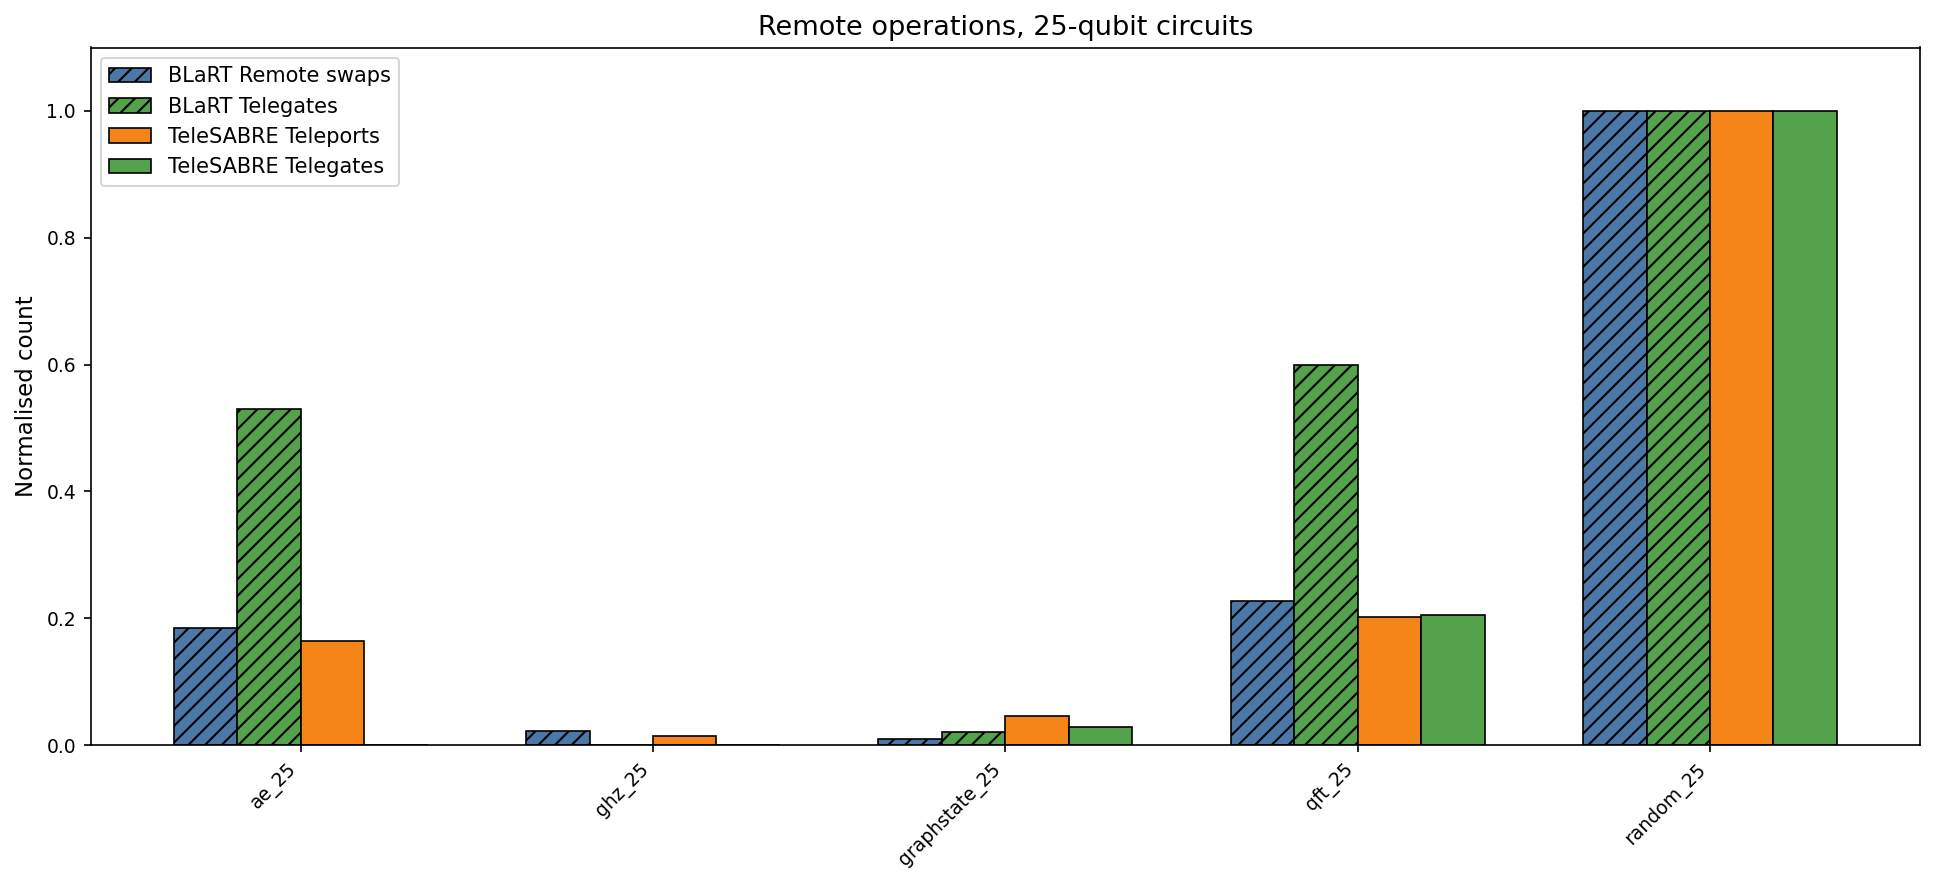

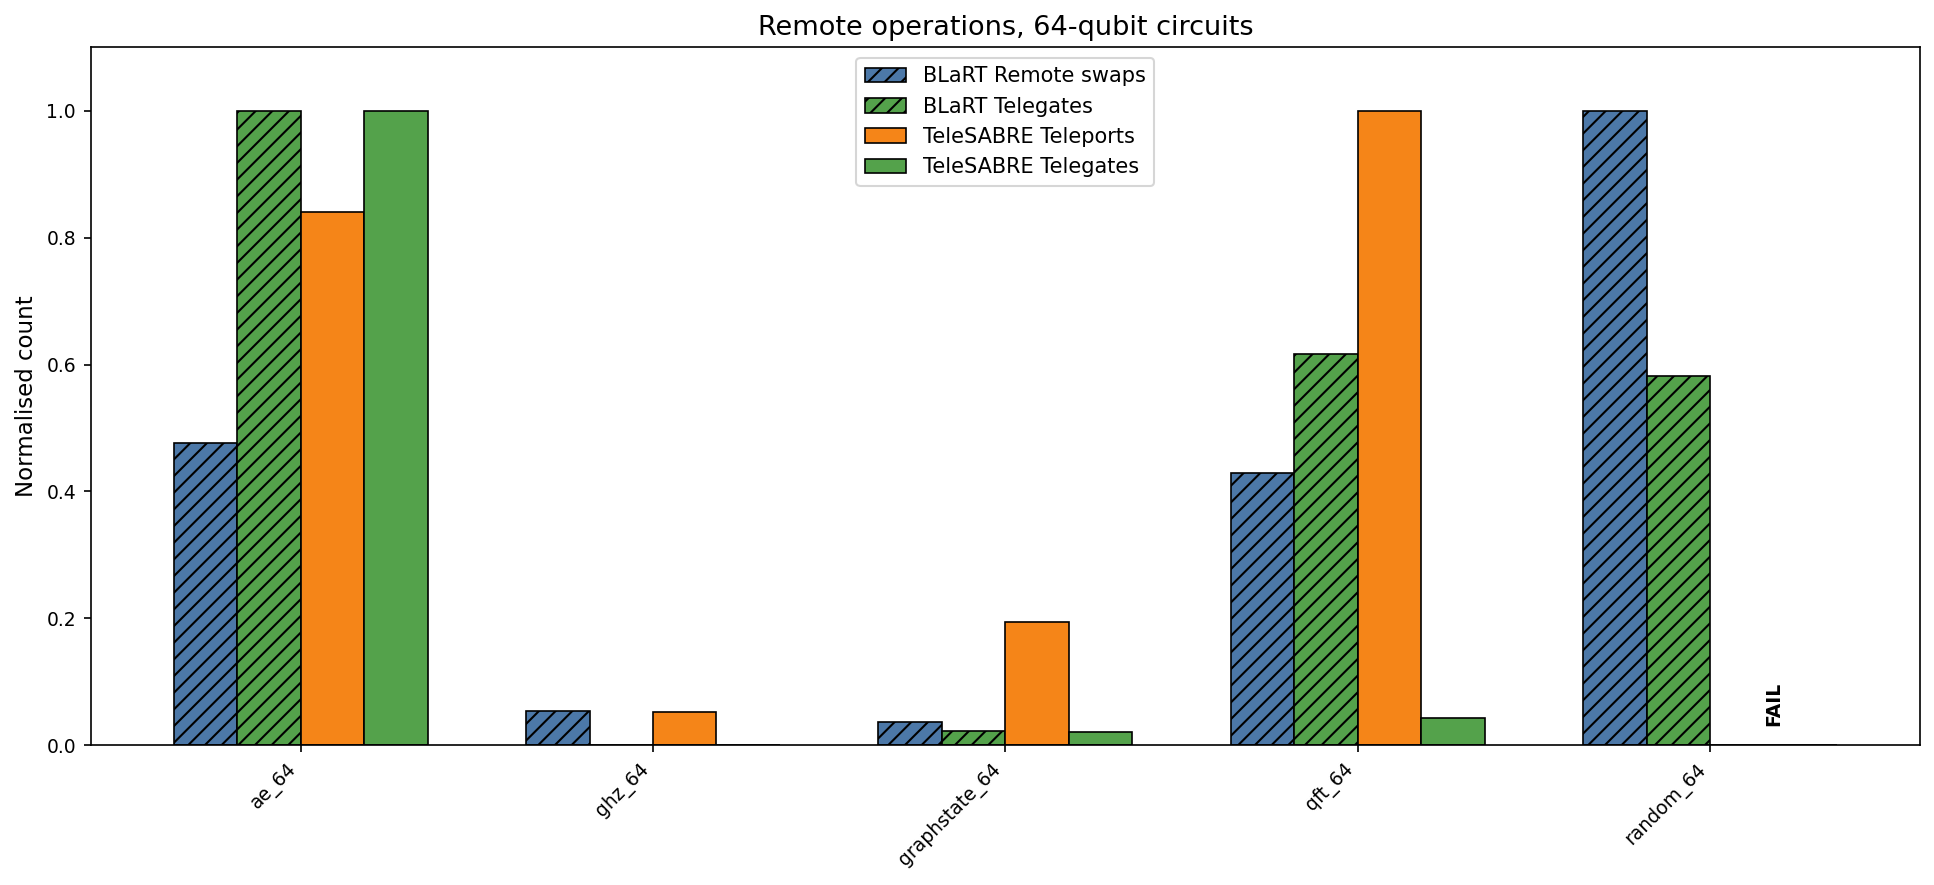

In [68]:
def normalise(arr, fail_mask=None):
    arr = arr.astype(float).copy()
    if fail_mask is not None:
        arr[fail_mask] = np.nan
    m = np.nanmax(arr)
    if np.isnan(m) or m == 0:
        return np.zeros_like(arr, dtype=float)
    return arr / m

def plot_normalised_ops_for_qubits(target_qubits):
    idx = np.where(num_qubits == target_qubits)[0]

    if len(idx) == 0:
        print(f"No circuits found for {target_qubits} qubits")
        return

    labels = [short_name(names[i]) for i in idx]
    x = np.arange(len(idx))
    width = 0.18

    # Raw counts
    b_rs = b_remote_swaps[idx].astype(float)
    b_tg = b_telegates[idx].astype(float)
    c_tp = tc_teleports[idx].astype(float).copy()
    c_tg = tc_telegates[idx].astype(float).copy()
    c_fail_local = tc_fail[idx]

    # Normalise separately within this qubit group
    b_rs_norm = normalise(b_rs)
    b_tg_norm = normalise(b_tg)
    c_tp_norm = normalise(c_tp, fail_mask=c_fail_local)
    c_tg_norm = normalise(c_tg, fail_mask=c_fail_local)

    fig, ax = plt.subplots(figsize=(13, 6))

    # BLaRTSABRE with pattern
    ax.bar(
        x - 1.5 * width, b_rs_norm, width,
        label="BLaRT Remote swaps",
        color="#4C78A8",
        hatch="///",
        edgecolor="black",
        linewidth=0.8
    )
    ax.bar(
        x - 0.5 * width, b_tg_norm, width,
        label="BLaRT Telegates",
        color="#54A24B",
        hatch="///",
        edgecolor="black",
        linewidth=0.8
    )

    # TeleSABRE without pattern
    ax.bar(
        x + 0.5 * width, np.nan_to_num(c_tp_norm, nan=0.0), width,
        label="TeleSABRE Teleports",
        color="#F58518",
        edgecolor="black",
        linewidth=0.8
    )
    ax.bar(
        x + 1.5 * width, np.nan_to_num(c_tg_norm, nan=0.0), width,
        label="TeleSABRE Telegates",
        color="#54A24B",
        edgecolor="black",
        linewidth=0.8
    )

    # Mark failed C runs
    for j, i in enumerate(idx):
        if tc_fail[i]:
            ax.text(
                x[j] + width, 0.03, "FAIL",
                rotation=90, ha="center", va="bottom",
                fontsize=9, fontweight="bold"
            )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Normalised count")
    ax.set_title(f"Remote operations, {target_qubits}-qubit circuits")
    ax.legend()
    plt.tight_layout()
    plt.show()

# Draw the two separate charts
plot_normalised_ops_for_qubits(25)
plot_normalised_ops_for_qubits(64)

---

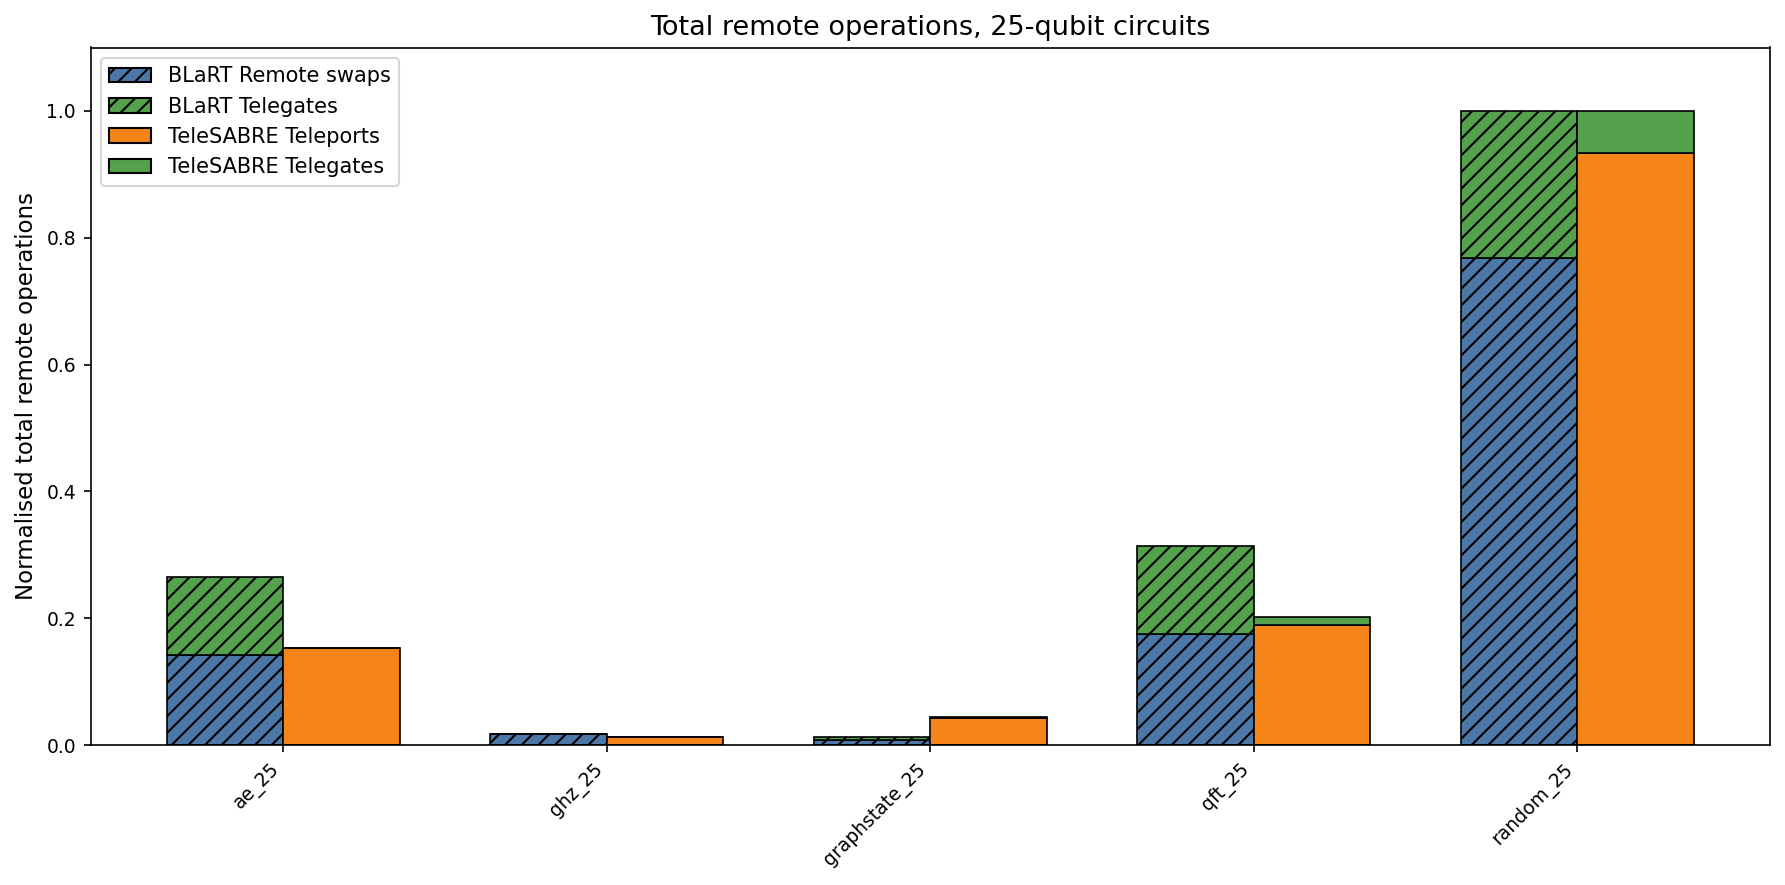

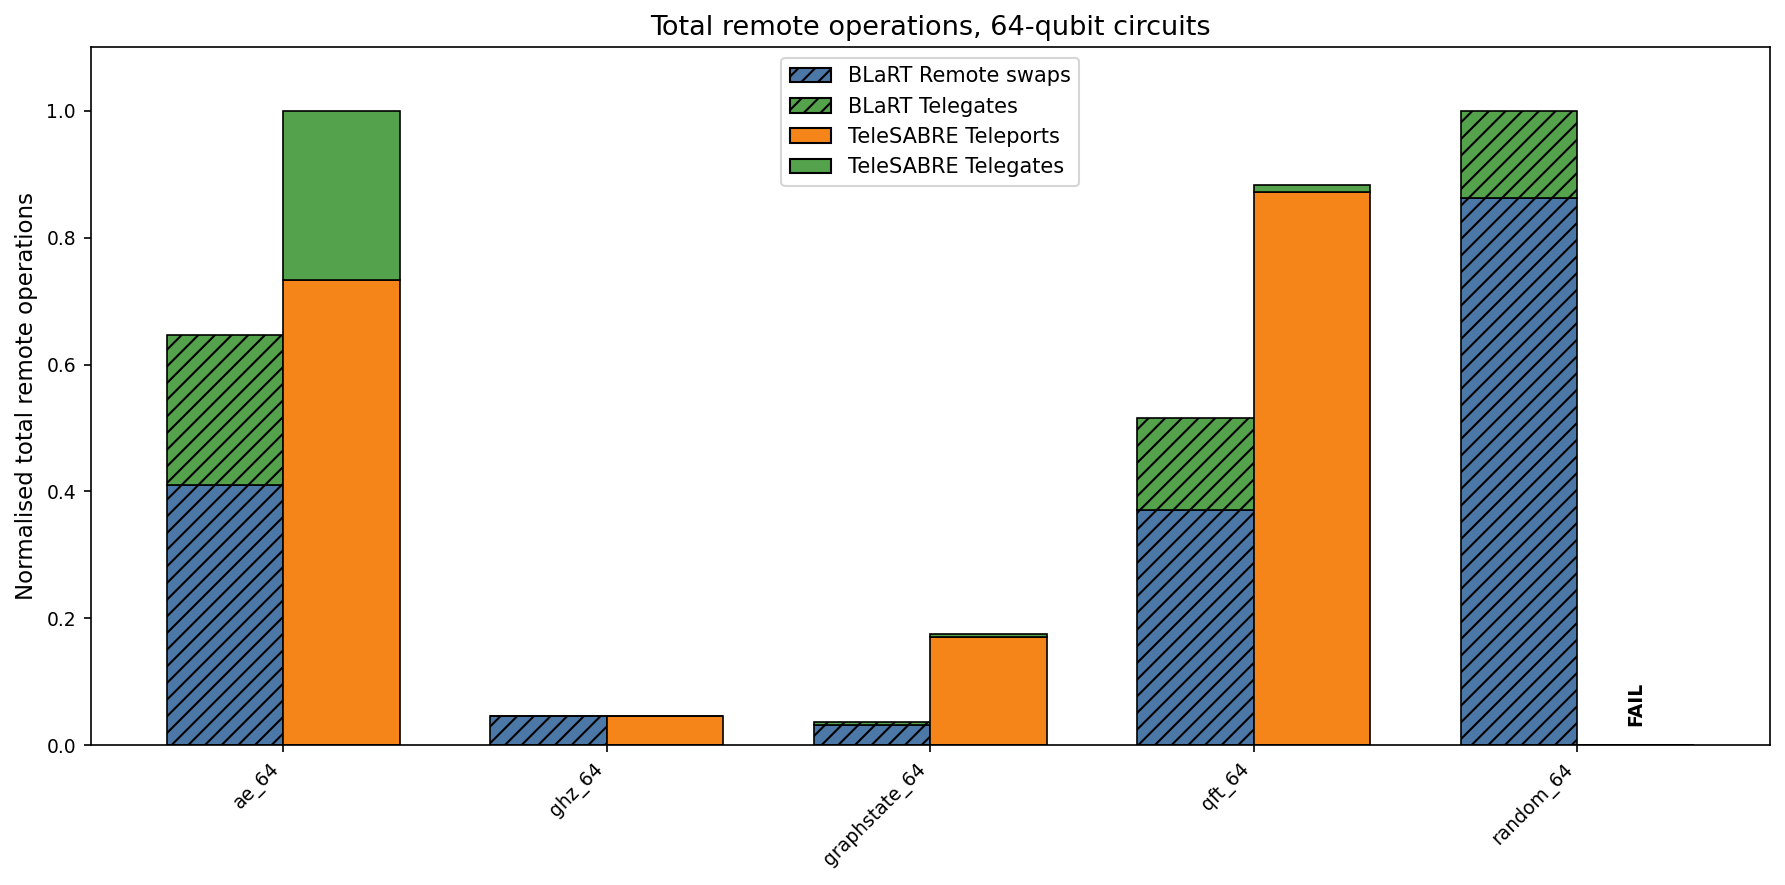

In [69]:
def plot_normalised_total_remote_ops(target_qubits):
    idx = np.where(num_qubits == target_qubits)[0]

    if len(idx) == 0:
        print(f"No circuits found for {target_qubits} qubits")
        return

    labels = [short_name(names[i]) for i in idx]
    x = np.arange(len(idx))
    width = 0.36

    # Raw components
    b_rs = b_remote_swaps[idx].astype(float)
    b_tg = b_telegates[idx].astype(float)

    c_tp = tc_teleports[idx].astype(float).copy()
    c_tg = tc_telegates[idx].astype(float).copy()
    c_fail_local = tc_fail[idx]

    # Totals
    b_total_remote = b_rs + b_tg
    c_total_remote = c_tp + c_tg

    # Exclude failed C runs from normalisation
    c_total_remote_masked = c_total_remote.copy()
    c_total_remote_masked[c_fail_local] = np.nan

    # Normalise each method separately within this qubit subset
    b_scale = np.max(b_total_remote) if np.max(b_total_remote) > 0 else 1.0
    c_scale = np.nanmax(c_total_remote_masked) if np.any(~np.isnan(c_total_remote_masked)) else 1.0
    if c_scale == 0:
        c_scale = 1.0

    b_rs_norm = b_rs / b_scale
    b_tg_norm = b_tg / b_scale

    c_tp_norm = c_tp / c_scale
    c_tg_norm = c_tg / c_scale
    c_tp_norm[c_fail_local] = 0.0
    c_tg_norm[c_fail_local] = 0.0

    fig, ax = plt.subplots(figsize=(12, 6))

    # BLaRTSABRE, patterned
    ax.bar(
        x - width/2, b_rs_norm, width,
        color="#4C78A8",
        hatch="///",
        edgecolor="black",
        linewidth=0.8,
        label="BLaRT Remote swaps"
    )
    ax.bar(
        x - width/2, b_tg_norm, width, bottom=b_rs_norm,
        color="#54A24B",
        hatch="///",
        edgecolor="black",
        linewidth=0.8,
        label="BLaRT Telegates"
    )

    # TeleSABRE, plain
    ax.bar(
        x + width/2, c_tp_norm, width,
        color="#F58518",
        edgecolor="black",
        linewidth=0.8,
        label="TeleSABRE Teleports"
    )
    ax.bar(
        x + width/2, c_tg_norm, width, bottom=c_tp_norm,
        color="#54A24B",
        edgecolor="black",
        linewidth=0.8,
        label="TeleSABRE Telegates"
    )

    # Mark FAIL on failed C runs
    for j, i in enumerate(idx):
        if tc_fail[i]:
            ax.text(
                x[j] + width/2, 0.03, "FAIL",
                rotation=90, ha="center", va="bottom",
                fontsize=9, fontweight="bold"
            )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Normalised total remote operations")
    ax.set_title(f"Total remote operations, {target_qubits}-qubit circuits")

    legend_handles = [
        Patch(facecolor="#4C78A8", edgecolor="black", hatch="///", label="BLaRT Remote swaps"),
        Patch(facecolor="#54A24B", edgecolor="black", hatch="///", label="BLaRT Telegates"),
        Patch(facecolor="#F58518", edgecolor="black", label="TeleSABRE Teleports"),
        Patch(facecolor="#54A24B", edgecolor="black", label="TeleSABRE Telegates"),
    ]
    ax.legend(handles=legend_handles)

    plt.tight_layout()
    plt.show()

# Draw separate charts
plot_normalised_total_remote_ops(25)
plot_normalised_total_remote_ops(64)

---

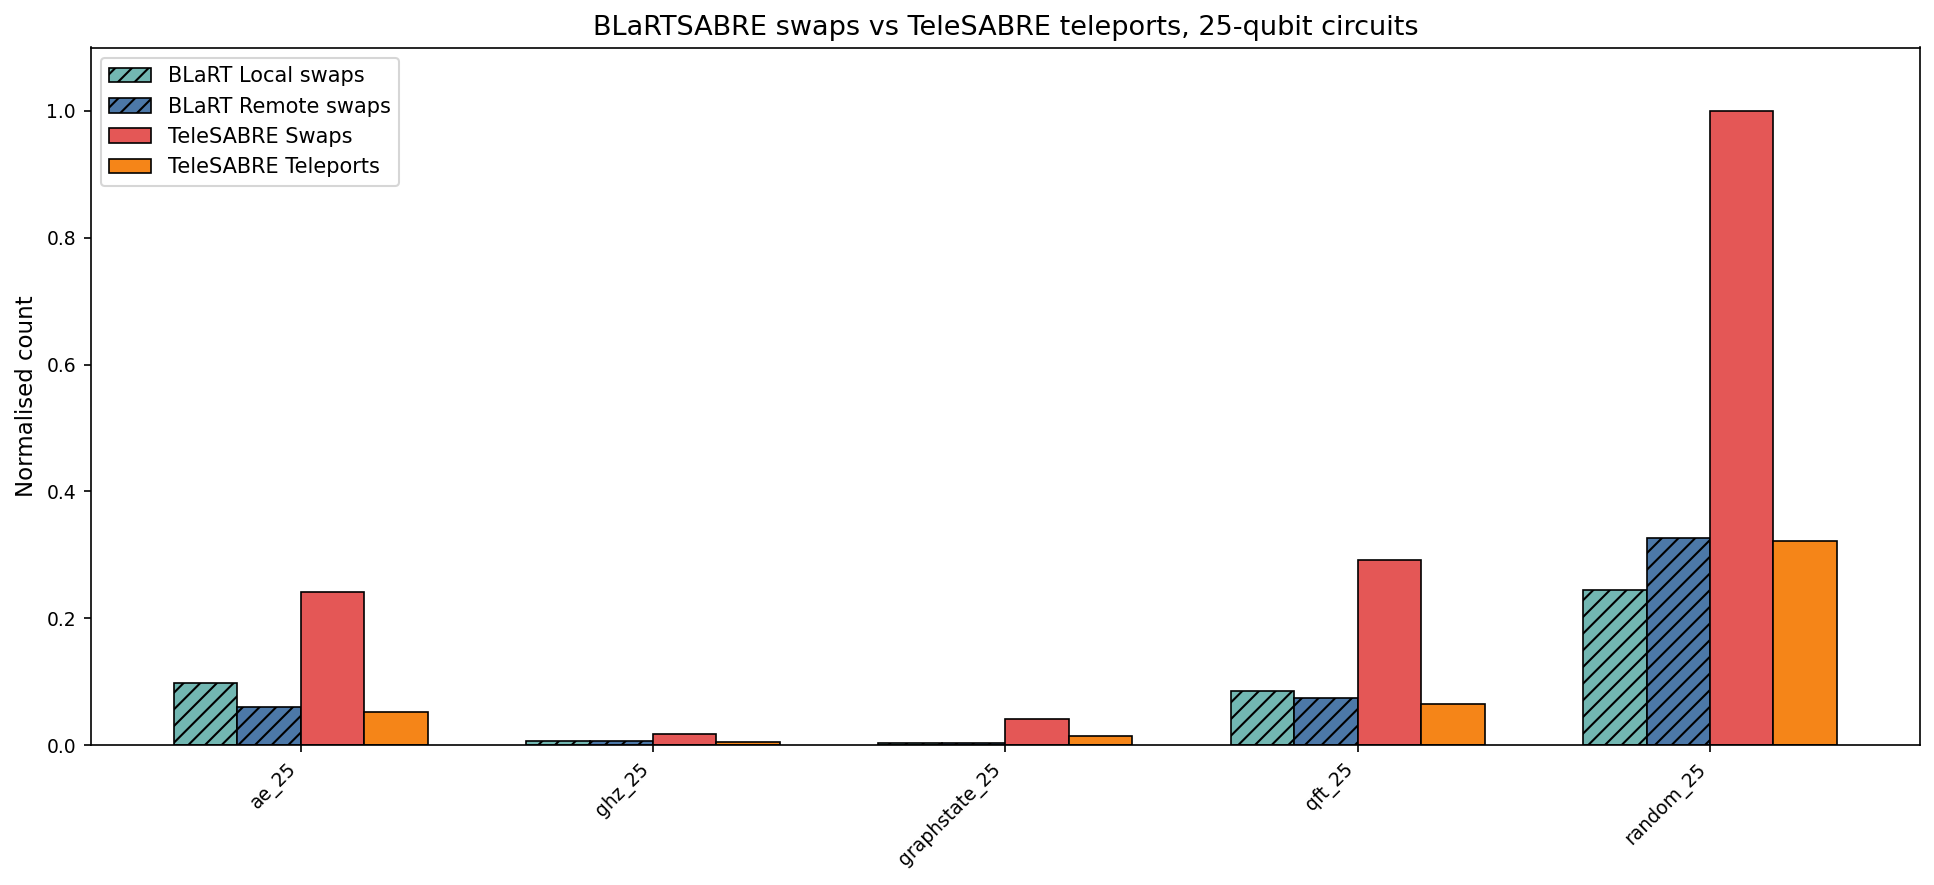

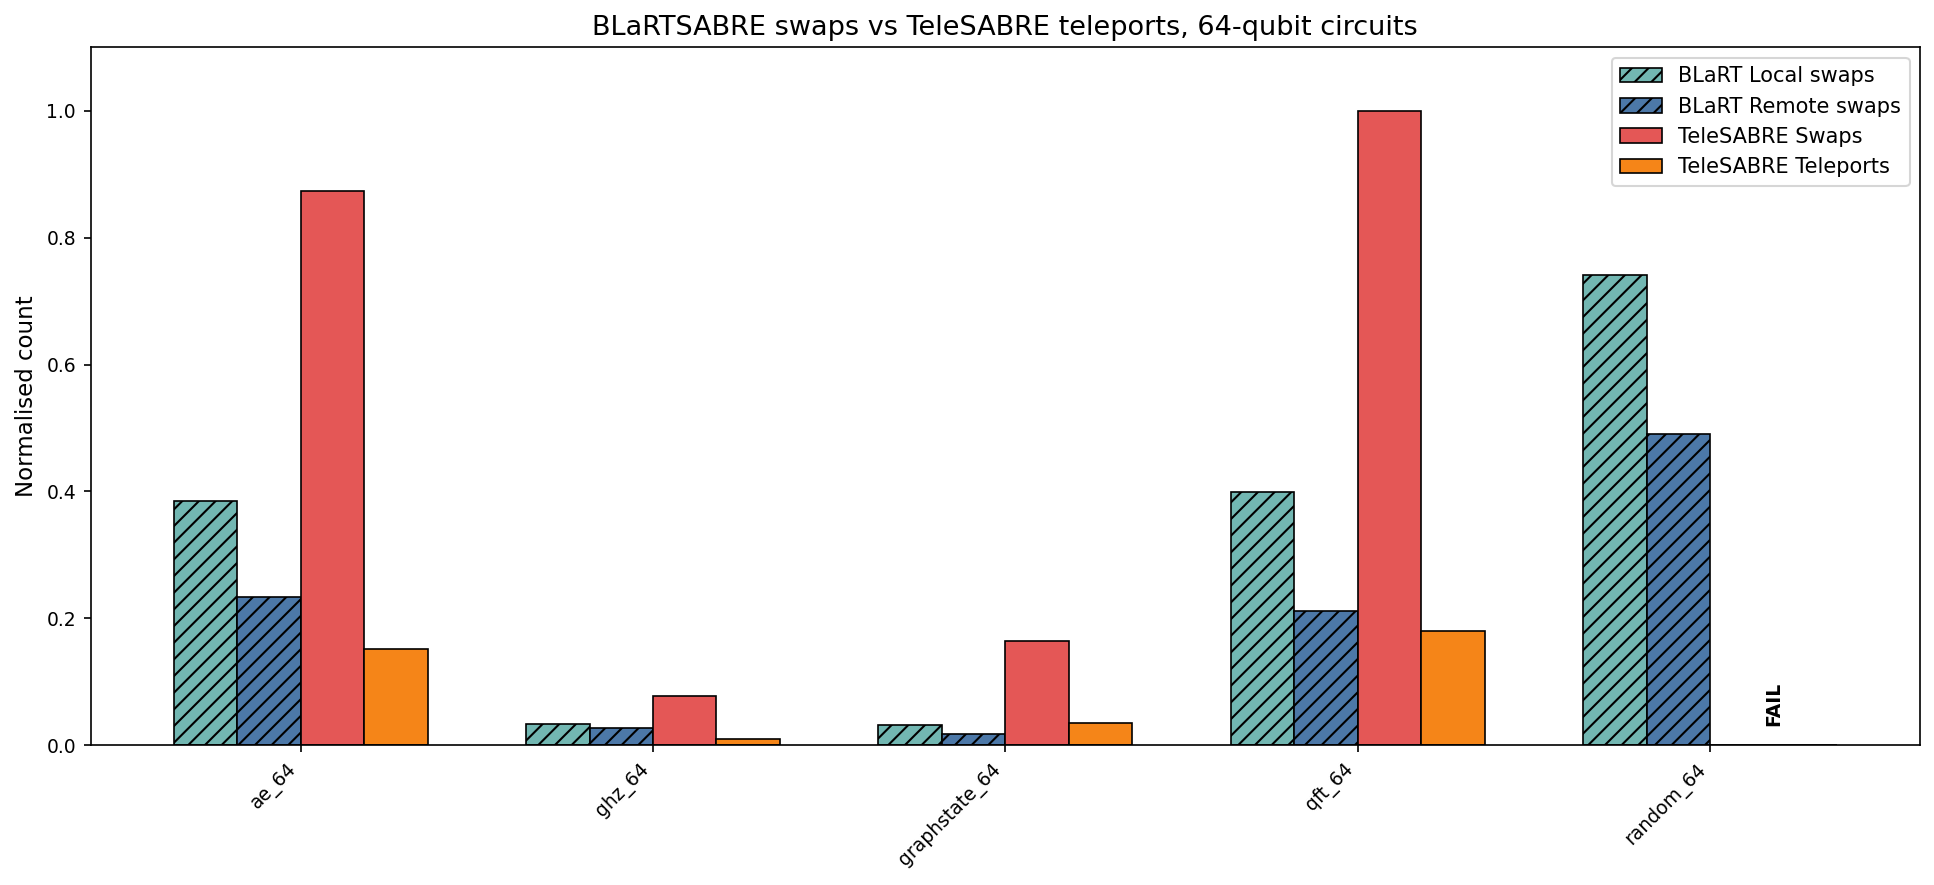

In [70]:
def plot_normalised_swap_breakdown(target_qubits):
    idx = np.where(num_qubits == target_qubits)[0]

    if len(idx) == 0:
        print(f"No circuits found for {target_qubits} qubits")
        return

    labels = [short_name(names[i]) for i in idx]
    x = np.arange(len(idx))
    width = 0.18

    # Raw counts
    b_ls = b_local_swaps[idx].astype(float)
    b_rs = b_remote_swaps[idx].astype(float)
    c_sw = tc_swaps[idx].astype(float).copy()
    c_tp = tc_teleports[idx].astype(float).copy()
    c_fail_local = tc_fail[idx]

    # Hide failed C values from normalisation
    c_sw_masked = c_sw.copy()
    c_tp_masked = c_tp.copy()
    c_sw_masked[c_fail_local] = np.nan
    c_tp_masked[c_fail_local] = np.nan

    # Common normalisation within this qubit subset
    common_scale = np.nanmax(
        np.concatenate([
            b_ls,
            b_rs,
            c_sw_masked[~np.isnan(c_sw_masked)],
            c_tp_masked[~np.isnan(c_tp_masked)]
        ])
    )
    if np.isnan(common_scale) or common_scale == 0:
        common_scale = 1.0

    b_ls_norm = b_ls / common_scale
    b_rs_norm = b_rs / common_scale
    c_sw_norm = c_sw / common_scale
    c_tp_norm = c_tp / common_scale

    # Failed C runs shown as 0 bars with FAIL marker
    c_sw_norm[c_fail_local] = 0.0
    c_tp_norm[c_fail_local] = 0.0

    fig, ax = plt.subplots(figsize=(13, 6))

    # BLaRTSABRE, patterned
    ax.bar(
        x - 1.5 * width, b_ls_norm, width,
        color="#72B7B2",
        hatch="///",
        edgecolor="black",
        linewidth=0.8,
        label="BLaRT Local swaps"
    )
    ax.bar(
        x - 0.5 * width, b_rs_norm, width,
        color="#4C78A8",
        hatch="///",
        edgecolor="black",
        linewidth=0.8,
        label="BLaRT Remote swaps"
    )

    # TeleSABRE, plain
    ax.bar(
        x + 0.5 * width, c_sw_norm, width,
        color="#E45756",
        edgecolor="black",
        linewidth=0.8,
        label="TeleSABRE Swaps"
    )
    ax.bar(
        x + 1.5 * width, c_tp_norm, width,
        color="#F58518",
        edgecolor="black",
        linewidth=0.8,
        label="TeleSABRE Teleports"
    )

    for j, i in enumerate(idx):
        if tc_fail[i]:
            ax.text(
                x[j] + width, 0.03, "FAIL",
                rotation=90, ha="center", va="bottom",
                fontsize=9, fontweight="bold"
            )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Normalised count")
    ax.set_title(f"BLaRTSABRE swaps vs TeleSABRE teleports, {target_qubits}-qubit circuits")
    ax.legend()

    plt.tight_layout()
    plt.show()

# Draw separate charts
plot_normalised_swap_breakdown(25)
plot_normalised_swap_breakdown(64)

---

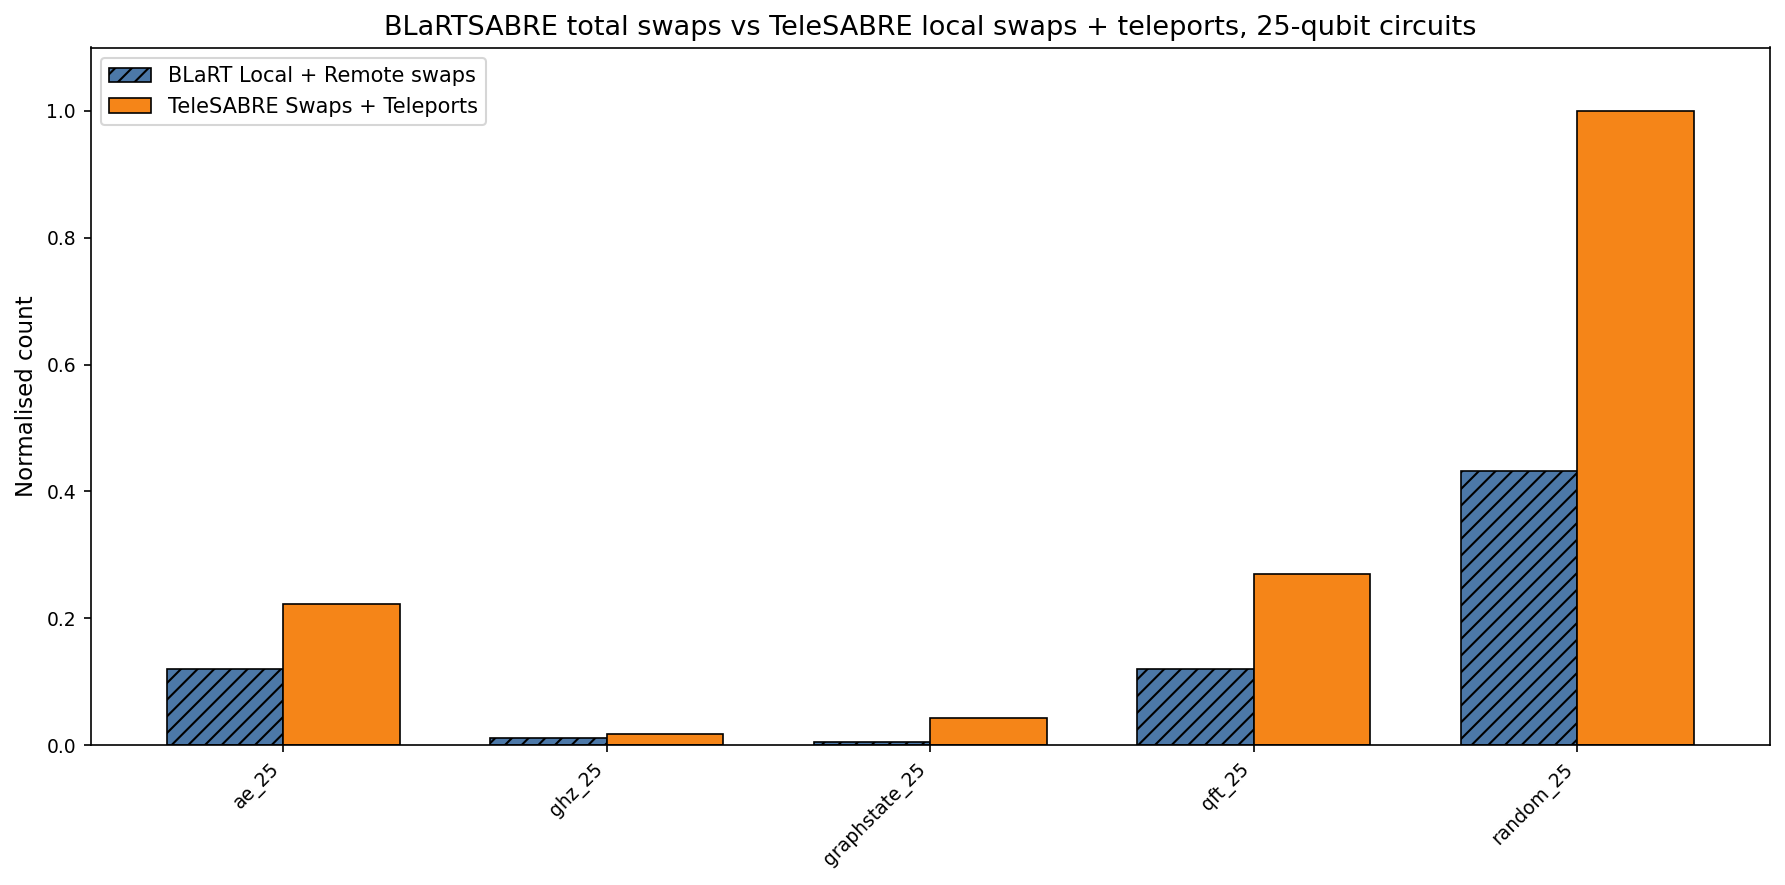

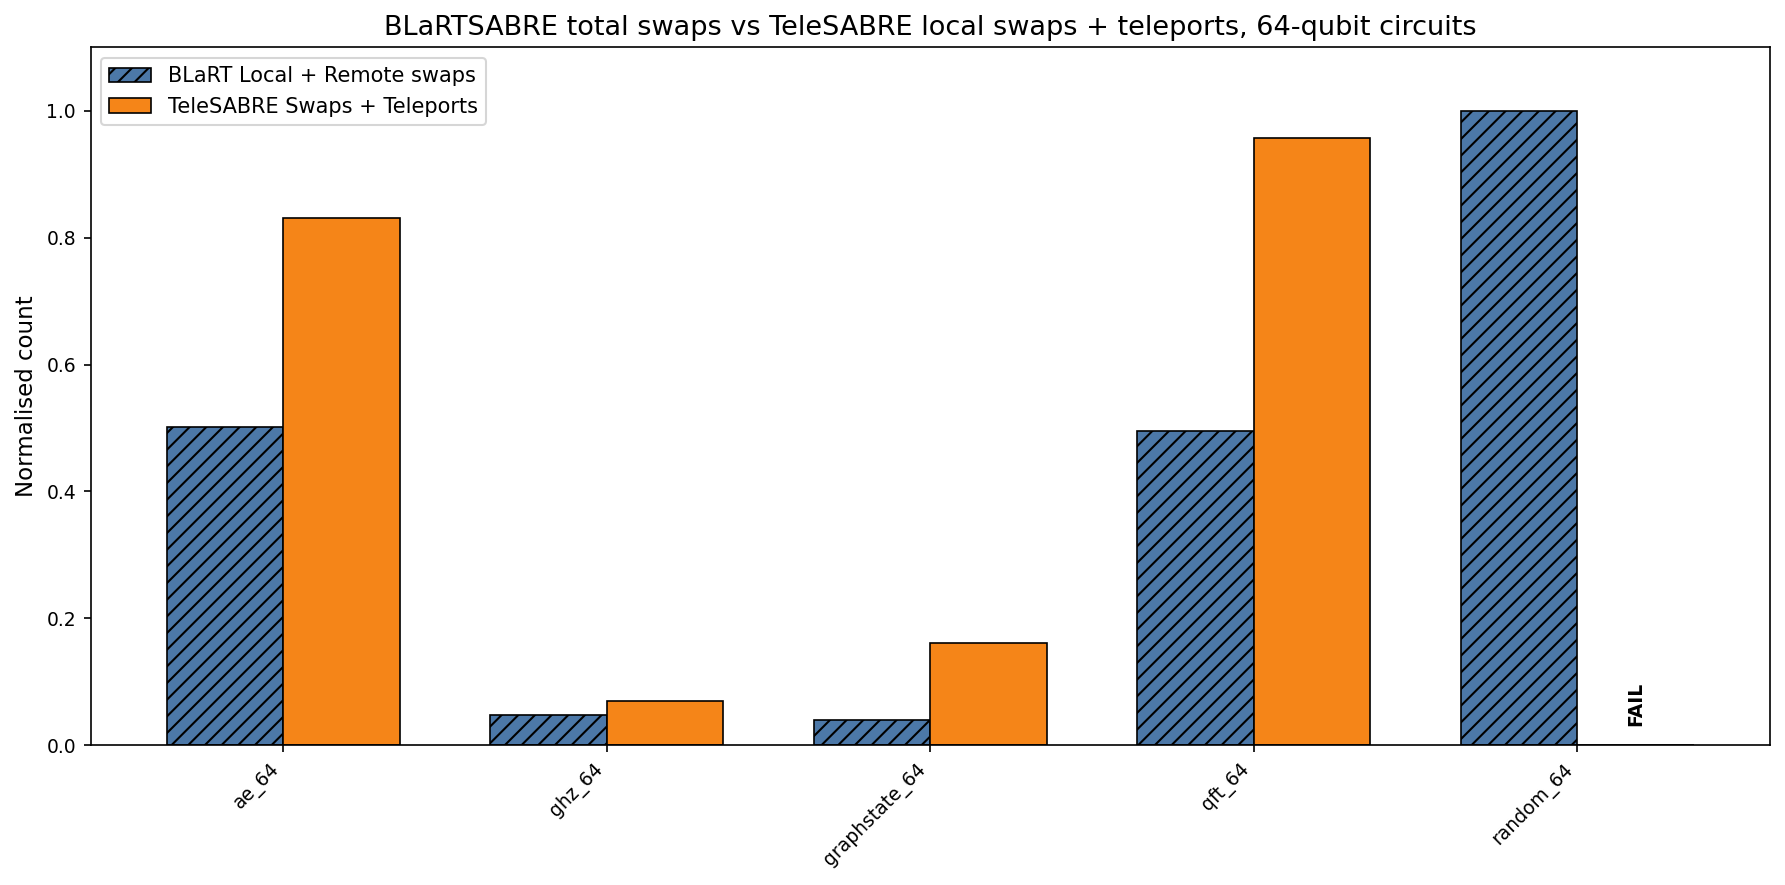

In [71]:
def plot_normalised_total_movement(target_qubits):
    idx = np.where(num_qubits == target_qubits)[0]

    if len(idx) == 0:
        print(f"No circuits found for {target_qubits} qubits")
        return

    labels = [short_name(names[i]) for i in idx]
    x = np.arange(len(idx))
    width = 0.36

    # Raw totals
    b_total_swaps_local_remote = (b_local_swaps[idx] + b_remote_swaps[idx]).astype(float)
    c_total_swaps_teleports = (tc_swaps[idx] + tc_teleports[idx]).astype(float)
    c_fail_local = tc_fail[idx]

    # Exclude failed C runs from scale
    c_total_masked = c_total_swaps_teleports.copy()
    c_total_masked[c_fail_local] = np.nan

    valid_parts = [b_total_swaps_local_remote]
    if np.any(~np.isnan(c_total_masked)):
        valid_parts.append(c_total_masked[~np.isnan(c_total_masked)])

    common_scale = np.nanmax(np.concatenate(valid_parts))
    if np.isnan(common_scale) or common_scale == 0:
        common_scale = 1.0

    b_norm = b_total_swaps_local_remote / common_scale
    c_norm = c_total_swaps_teleports / common_scale
    c_norm[c_fail_local] = 0.0

    fig, ax = plt.subplots(figsize=(12, 6))

    # BLaRTSABRE, patterned
    ax.bar(
        x - width/2, b_norm, width,
        color="#4C78A8",
        hatch="///",
        edgecolor="black",
        linewidth=0.8,
        label="BLaRT Local + Remote swaps"
    )

    # TeleSABRE, plain
    ax.bar(
        x + width/2, c_norm, width,
        color="#F58518",
        edgecolor="black",
        linewidth=0.8,
        label="TeleSABRE Swaps + Teleports"
    )

    # Mark failed C runs
    for j, i in enumerate(idx):
        if tc_fail[i]:
            ax.text(
                x[j] + width/2, 0.03, "FAIL",
                rotation=90, ha="center", va="bottom",
                fontsize=9, fontweight="bold"
            )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Normalised count")
    ax.set_title(f"BLaRTSABRE total swaps vs TeleSABRE local swaps + teleports, {target_qubits}-qubit circuits")
    ax.legend()

    plt.tight_layout()
    plt.show()

# Draw separate charts
plot_normalised_total_movement(25)
plot_normalised_total_movement(64)